In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import librosa
import joblib
from google.colab import drive
from tqdm.notebook import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf

# ─── CONFIGURACIÓN DE RUTAS ───────────────────────────────────
drive.mount('/content/drive')

# Rutas de origen y destino
ZIP_PATH = '/content/drive/MyDrive/audios_proyecto.zip' # Ajusta el nombre de tu zip
LOCAL_DIR = '/content/audios_local/'
DRIVE_PATH = '/content/drive/MyDrive/data_set_ia/'

# ─── DESCOMPRESIÓN LOCAL (El secreto de la velocidad) ─────────
if not os.path.exists(LOCAL_DIR):
    print("📦 Extrayendo audios al disco local de Colab...")
    os.makedirs(LOCAL_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_DIR)
    print("✅ Extracción completa.")

# Carga del DataFrame
df = pd.read_csv(DRIVE_PATH + "df_features.csv").iloc[:, :4]

# ─── EXTRACCIÓN DE CARACTERÍSTICAS (PARALELA Y LOCAL) ─────────
SR = 22050
N_MELS = 128
PAD_SIZE = 20000

SUBFOLDER = "seleccionados/" # Déjalo vacío "" si los archivos están sueltos en audios_local
ACTUAL_LOCAL_PATH = os.path.join(LOCAL_DIR, SUBFOLDER)

def fast_extract(row_data):
    path, age, acc, gen = row_data
    # Intentamos construir la ruta completa
    file_path = os.path.join(ACTUAL_LOCAL_PATH, path)

    # Si el path del CSV ya trae "seleccionados/", esto evita duplicarlo
    if not os.path.exists(file_path):
        file_path = os.path.join(LOCAL_DIR, path)

    if not os.path.exists(file_path):
        return None # Aquí es donde estaba saltando antes

    try:
        wav, _ = librosa.load(file_path, sr=SR, duration=5.0)
        melspec = librosa.feature.melspectrogram(y=wav, sr=SR, n_mels=N_MELS)
        melspec_flat = melspec.flatten()

        if len(melspec_flat) >= PAD_SIZE:
            padded = melspec_flat[:PAD_SIZE]
        else:
            padded = np.pad(melspec_flat, (0, PAD_SIZE - len(melspec_flat)), mode='constant')

        return padded, age, acc, gen
    except:
        return None

print(f"🚀 Iniciando extracción desde disco local ({len(df)} archivos)...")
# Convertimos df a lista de tuplas para joblib
data_to_process = list(df[['path', 'age', 'accents', 'gender']].itertuples(index=False, name=None))

# Paralelización masiva
results = joblib.Parallel(n_jobs=-1, batch_size=10)(
    joblib.delayed(fast_extract)(item) for item in tqdm(data_to_process)
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Iniciando extracción desde disco local (24343 archivos)...


  0%|          | 0/24343 [00:00<?, ?it/s]

In [ ]:
results = [r for r in results if r is not None]
X = np.array([r[0] for r in results], dtype=np.float32)
y_age = [r[1] for r in results]
y_acc = [r[2] for r in results]
y_gen = [r[3] for r in results]

In [ ]:
import joblib

# Ruta en tu Drive (ajústala si es necesario)
ruta_backup = "/content/drive/MyDrive/data_set_ia/resultados_backup.joblib"

print("💾 Guardando copia de seguridad de la lista completa...")
joblib.dump(results, ruta_backup)
print("✅ ¡Salvados! Tu progreso está seguro en Drive.")

💾 Guardando copia de seguridad de la lista completa...
✅ ¡Salvados! Tu progreso está seguro en Drive.


# **CARGAR DATASET**

In [ ]:
import joblib
import numpy as np
import gc

# 1. Cargar la copia de seguridad desde Drive
ruta_backup = "/content/drive/MyDrive/data_set_ia/resultados_backup.joblib"
print("📦 Cargando datos desde Drive (esto puede tomar un minuto)...")
results = joblib.load(ruta_backup)

# 2. Limpiar posibles errores y extraer etiquetas
print("🏷️ Extrayendo etiquetas (targets)...")
results = [r for r in results if r is not None]

y_age = np.array([r[1] for r in results])
y_acc = np.array([r[2] for r in results])
y_gen = np.array([r[3] for r in results])

# 3. Construir la matriz X de forma segura para la RAM
print("🏗️ Construyendo la matriz X optimizada...")
num_audios = len(results)
PAD_SIZE = len(results[0][0])

# Pre-asignamos la matriz en float16 para ahorrar un 50% de memoria RAM
X = np.empty((num_audios, PAD_SIZE), dtype=np.float16)

for i in range(num_audios):
    X[i] = results[i][0]
    # Borramos el dato de la lista original a medida que lo pasamos a la matriz
    results[i] = None

    if i % 5000 == 0:
        gc.collect() # Forzamos al sistema a liberar la basura

# Limpiamos los restos de la lista original
del results
gc.collect()

print("✅ ¡Operación exitosa!")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y_age: {y_age.shape}")

📦 Cargando datos desde Drive (esto puede tomar un minuto)...
🏷️ Extrayendo etiquetas (targets)...
🏗️ Construyendo la matriz X optimizada...
✅ ¡Operación exitosa!
Dimensiones de X: (24343, 20000)
Dimensiones de y_age: (24343,)


# **DISCRETIZACIÓN**

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
y_age_enc = LabelEncoder().fit_transform(y_age)
y_acc_enc = LabelEncoder().fit_transform(y_acc)
y_gen_enc = LabelEncoder().fit_transform(y_gen)

In [ ]:
le = LabelEncoder()
le.fit(y_age)
print(dict(zip(le.transform(le.classes_), le.classes_)))
le.fit(y_acc)
print(dict(zip(le.transform(le.classes_), le.classes_)))
le.fit(y_gen)
print(dict(zip(le.transform(le.classes_), le.classes_)))

{np.int64(0): np.str_('fifties'), np.int64(1): np.str_('fourties'), np.int64(2): np.str_('sixties'), np.int64(3): np.str_('teens'), np.int64(4): np.str_('thirties'), np.int64(5): np.str_('twenties')}
{np.int64(0): np.str_('América central'), np.int64(1): np.str_('Andino-Pacífico'), np.int64(2): np.str_('Caribe'), np.int64(3): np.str_('Chile'), np.int64(4): np.str_('España'), np.int64(5): np.str_('México'), np.int64(6): np.str_('Rioplatense')}
{np.int64(0): np.str_('female_feminine'), np.int64(1): np.str_('male_masculine')}


# **PARTICIONES**

In [ ]:
#@title **EDAD**
y_age = y_age_enc

In [ ]:
from sklearn.model_selection import train_test_split
#separamos en train y test
X_train, X_test, y_train, y_test= train_test_split(X, y_age_enc, test_size=0.2, random_state=42)
#se separa el validation y test
X_val,X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)


In [ ]:
#@title **ACENTO**
y_acc = y_acc_enc

In [ ]:
#separamos en train y test
X_train_acc, X_test_acc, y_train_acc, y_test_acc= train_test_split(X, y_acc, test_size=0.2, random_state=42)
#se separa el validation y test
X_val_acc,X_test_acc, y_val_acc, y_test_acc = train_test_split(X_test_acc, y_test_acc, test_size=0.5, random_state=42)

In [ ]:
#@title **GÉNERO**
y_gen = y_gen_enc

In [ ]:
from sklearn.model_selection import train_test_split
#separamos en train y test
X_train_gen, X_test_gen, y_train_gen, y_test_gen= train_test_split(X, y_gen, test_size=0.2, random_state=42)
#se separa el validation y test
X_val_gen,X_test_gen, y_val_gen, y_test_gen = train_test_split(X_test_gen, y_test_gen, test_size=0.5, random_state=42)

# **DEEP LEARNING**

In [ ]:
import tensorflow as tf

#@title **EDAD**
#Se aplica OHE
try:
    del X
    del results
    gc.collect()
except:
    pass
y_train_ohe = tf.keras.utils.to_categorical(y_train, num_classes=6)
y_val_ohe   = tf.keras.utils.to_categorical(y_val,   num_classes=6)
y_test_ohe  = tf.keras.utils.to_categorical(y_test,  num_classes=6)

print(y_train_ohe.shape, y_val_ohe.shape, y_test_ohe.shape)

(19474, 6) (2434, 6) (2435, 6)


In [ ]:
from tensorflow.keras import layers, models, regularizers
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=X_train[0].shape),
    tf.keras.layers.Dense(512, activation='elu'),
    tf.keras.layers.Dense(256, activation='elu'),
    tf.keras.layers.Dense(128, activation='elu'),
    tf.keras.layers.Dense(6, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,240,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,405,510 (39.69 MB)

 Trainable params: 10,405,510 (39.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print(X_train.shape, y_train_ohe.shape)
print(X_val.shape, y_val_ohe.shape)
print(X_test.shape, y_test_ohe.shape)

(19474, 20000) (19474, 6)
(2434, 20000) (2434, 6)
(2435, 20000) (2435, 6)


In [ ]:
history = model.fit(
    X_train, y_train_ohe,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val_ohe),
    verbose=1
)

Epoch 1/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.2421 - loss: 5.1424 - val_accuracy: 0.2280 - val_loss: 2.0196
Epoch 2/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3166 - loss: 2.1212 - val_accuracy: 0.2358 - val_loss: 6.9632
Epoch 3/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3443 - loss: 2.8301 - val_accuracy: 0.3098 - val_loss: 2.5203
Epoch 4/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3738 - loss: 1.9668 - val_accuracy: 0.2687 - val_loss: 2.0723
Epoch 5/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4123 - loss: 1.6219 - val_accuracy: 0.3295 - val_loss: 1.8341
Epoch 6/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4679 - loss: 1.4626 - val_accuracy: 0.3431 - val_loss: 1.8579
Epoch 7/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5053 - loss: 1.3269 - val_accuracy: 0.3233 - val_loss: 1.9090
Epoch 8/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5459 - loss: 1.2374 - val_accuracy: 0

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_ohe)
print( 'Test accuracy:', test_acc, " test_loss: ", test_loss)

InvalidArgumentError: Graph execution error:

Detected at node compile_loss/categorical_crossentropy/softmax_cross_entropy_with_logits defined at (most recent call last):
<stack traces unavailable>
Dimensions cannot be made to match through broadcasting

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start
File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once
File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
File "/usr

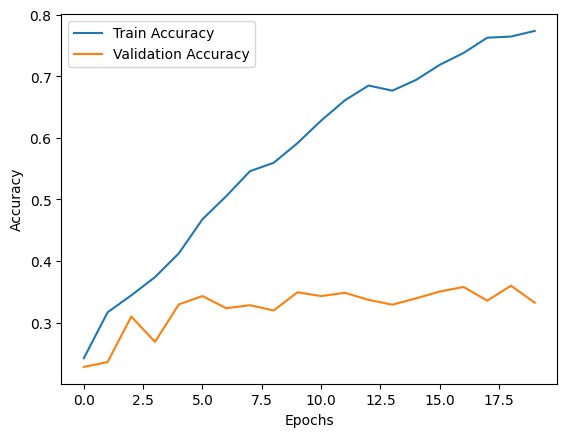

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [ ]:
#@title **ACENTOS**
#Se aplica OHE
y_train_acc_ohe = tf.keras.utils.to_categorical(y_train_acc, num_classes=7)
y_val_acc_ohe   = tf.keras.utils.to_categorical(y_val_acc,   num_classes=7)
y_test_acc_ohe  = tf.keras.utils.to_categorical(y_test_acc,  num_classes=7)

print(y_train_acc_ohe.shape, y_val_acc_ohe.shape, y_test_acc_ohe.shape)

(19474, 7) (2434, 7) (2435, 7)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=X_train_acc[0].shape),
    tf.keras.layers.Dense(512, activation='elu'),
    tf.keras.layers.Dense(256, activation='elu'),
    tf.keras.layers.Dense(128, activation='elu'),
    tf.keras.layers.Dense(7,   activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    10,240,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,405,639 (39.69 MB)

 Trainable params: 10,405,639 (39.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_acc = model.fit(
    X_train_acc, y_train_acc_ohe,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_acc, y_val_acc_ohe),
    verbose=1
)

Epoch 1/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2426 - loss: 6.1946 - val_accuracy: 0.2564 - val_loss: 2.1693
Epoch 2/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3648 - loss: 1.9071 - val_accuracy: 0.3024 - val_loss: 2.0938
Epoch 3/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4701 - loss: 1.5950 - val_accuracy: 0.3003 - val_loss: 2.3188
Epoch 4/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5606 - loss: 1.3709 - val_accuracy: 0.3328 - val_loss: 2.3989
Epoch 5/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6614 - loss: 1.1001 - val_accuracy: 0.3250 - val_loss: 2.6313
Epoch 6/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7082 - loss: 0.9924 - val_accuracy: 0.3303 - val_loss: 2.9458
Epoch 7/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7437 - loss: 0.9141 - val_accuracy: 0.3385 - val_loss: 3.0522
Epoch 8/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7953 - loss: 0.7359 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = model.evaluate(X_test_acc, y_test_acc_ohe)
print( 'Test accuracy:', test_acc, " test_loss: ", test_loss)

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3524 - loss: 4.9792
Test accuracy: 0.35236141085624695  test_loss:  4.979189872741699


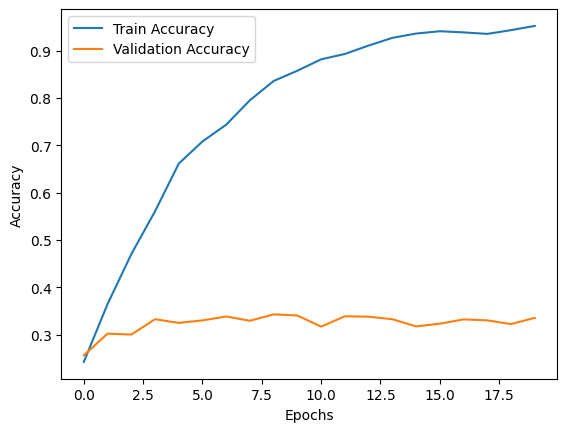

In [ ]:
plt.plot(history_acc.history['accuracy'],     label='Train Accuracy')
plt.plot(history_acc.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
#@title **GÉNERO**
#No se aplica OHE porq se usa sigmoid
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=X_train_gen[0].shape),
    tf.keras.layers.Dense(512, activation='elu'),
    tf.keras.layers.Dense(256, activation='elu'),
    tf.keras.layers.Dense(128, activation='elu'),
    tf.keras.layers.Dense(1,   activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,240,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,404,865 (39.69 MB)

 Trainable params: 10,404,865 (39.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Entrenar sin OHE
history_gen = model.fit(
    X_train_gen, y_train_gen,        # ← sin _ohe
    epochs=20,
    batch_size=32,
    validation_data=(X_val_gen, y_val_gen),  # ← sin _ohe
    verbose=1
)

Epoch 1/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8174 - loss: 1.6931 - val_accuracy: 0.8455 - val_loss: 0.7149
Epoch 2/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8882 - loss: 0.5399 - val_accuracy: 0.8689 - val_loss: 0.5650
Epoch 3/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9364 - loss: 0.2577 - val_accuracy: 0.8677 - val_loss: 0.6101
Epoch 4/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9454 - loss: 0.2337 - val_accuracy: 0.8841 - val_loss: 0.7424
Epoch 5/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9691 - loss: 0.1181 - val_accuracy: 0.8772 - val_loss: 0.9517
Epoch 6/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9744 - loss: 0.1424 - val_accuracy: 0.8866 - val_loss: 0.9486
Epoch 7/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9830 - loss: 0.0824 - val_accuracy: 0.8689 - val_loss: 1.0363
Epoch 8/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9839 - loss: 0.1453 - val_accuracy: 0

In [ ]:
test_loss, test_gen = model.evaluate(X_test_gen, y_test_gen)
print('Test accuracy:', test_gen, " test_loss: ", test_loss)

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8957 - loss: 2.7832
Test accuracy: 0.8956878781318665  test_loss:  2.7831735610961914


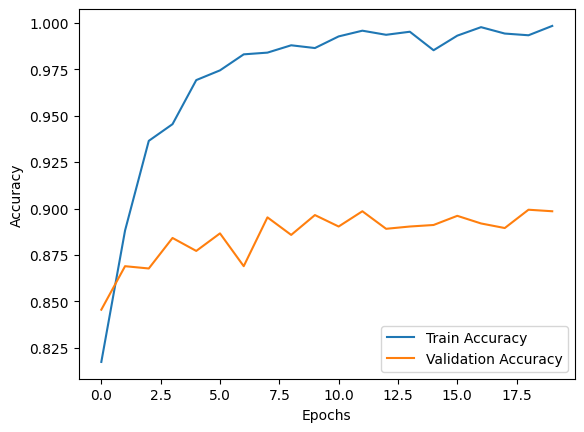

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history_gen.history['accuracy'],     label='Train Accuracy')
plt.plot(history_gen.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()